# 04_Math_Intuition.ipynb — Polynomial Regression

---

# Final Formula(s)

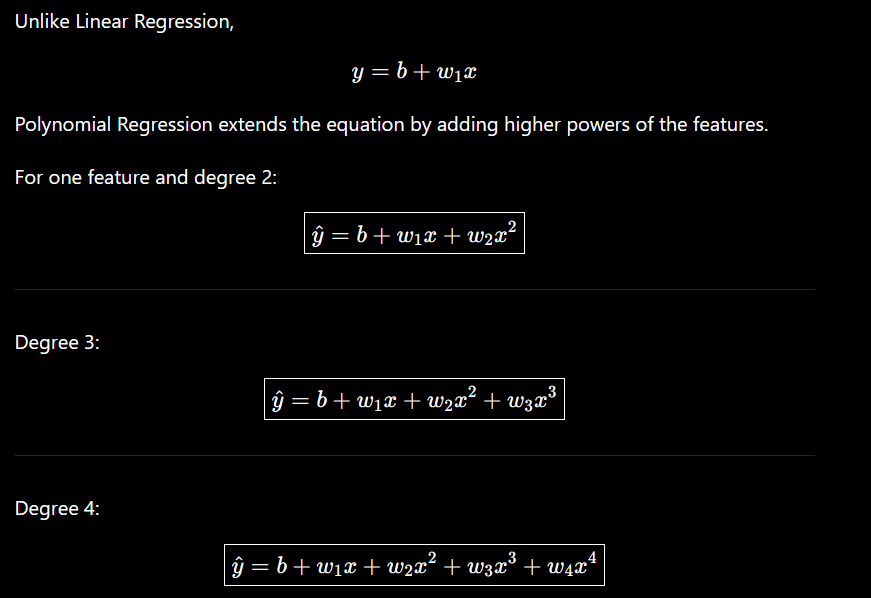

---

For multiple features:

Suppose

```text
x₁ = Age

x₂ = Experience
```

Degree = 2

The model becomes

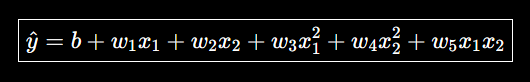

Notice

Polynomial Regression simply creates **more input features**.

---

# Meaning of Every Symbol

For

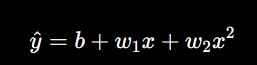

| Symbol   | Meaning                                         |
| -------- | ----------------------------------------------- |
| (\hat y) | Predicted value                                 |
| (b)      | Intercept (bias)                                |
| (w_1)    | Weight for x                                    |
| (w_2)    | Weight for x²                                   |
| (x)      | Original feature                                |
| (x^2)    | Squared feature generated by PolynomialFeatures |

---

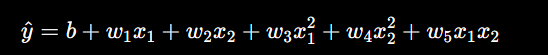

Additional symbols

| Symbol   | Meaning             |
| -------- | ------------------- |
| (x_1)    | Feature 1           |
| (x_2)    | Feature 2           |
| (x_1x_2) | Interaction feature |
| (x_1^2)  | Square of Feature 1 |
| (x_2^2)  | Square of Feature 2 |

---

# Why This Formula Works

This is the most important mathematical intuition.

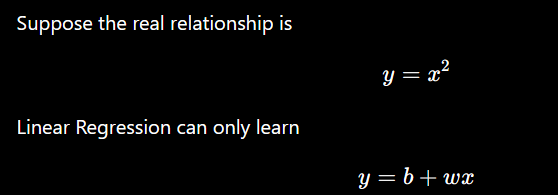

A straight line can never perfectly approximate a parabola.

Instead,

Polynomial Regression transforms

```text
x
```

into

```text
x

x²
```

Now the Linear Regression model learns

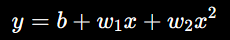

If it finds

```text
b = 0

w₁ = 0

w₂ = 1
```

then

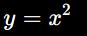
Exactly.

So the improvement comes **from richer input features**, not from a different optimization algorithm.

---

# Geometry Intuition

Imagine data shaped like this.

```text
y
|
|        •
|     •
|   •
| •
|    •
|        •
+---------------- x
```

---

## Linear Regression

It tries to fit

```text
y
|
|       •
|     •
|   •
| •
|---------
+---------------- x
```

The straight line misses the curve.

---

## Polynomial Regression

It creates

```text
x

x²
```

The model now has enough flexibility to fit

```text
y
|
|       •
|     •
|   •
| •
|  )
| )
|)
+---------------- x
```

---

## What Actually Happened?

Many students think

> "The algorithm bends the line."

It doesn't.

Instead,

The algorithm changes the **feature space**.

Original space

```text
x
```

↓

Expanded space

```text
x

x²
```

In this new space,

a linear combination of the features corresponds to a curved relationship in the original input space.

---

# Optimization Intuition

This is another misconception.

Polynomial Regression **does not have a different optimizer**.

Suppose

Degree = 2

The transformed matrix is

| x | x² |
| - | -- |
| 1 | 1  |
| 2 | 4  |
| 3 | 9  |

Linear Regression treats this exactly like any other feature matrix.

It minimizes the same Mean Squared Error (MSE):

[
\boxed{
J=\frac1n\sum_{i=1}^{n}(y_i-\hat y_i)^2
}
]

The only difference is that (\hat y) now depends on the expanded feature set.

So:

```text
PolynomialFeatures
        ↓
New Feature Matrix
        ↓
Ordinary Linear Regression
        ↓
Same Optimization
```

Nothing changes in the optimization process itself.

---

# Hyperparameter Effect

The primary hyperparameter is **degree**.

## Degree = 1

```text
Simple Model

High Bias

Low Variance
```

Equivalent to ordinary Linear Regression.

---

## Degree = 2

```text
Can model quadratic curves

Usually a good first choice
```

---

## Degree = 3

```text
Can model cubic (S-shaped) curves

More flexible
```

---

## Degree = 4–5

```text
Fits more complex relationships

Higher risk of overfitting
```

---

## Degree = 10

```text
Very flexible

Can memorize noise

High variance
```

---

### Bias–Variance Trend

| Degree | Bias     | Variance  |
| ------ | -------- | --------- |
| 1      | High     | Low       |
| 2      | Medium   | Medium    |
| 3      | Lower    | Higher    |
| 10     | Very Low | Very High |

---

### Practical Rule

Never choose the degree based on intuition alone.

Use **cross-validation**.

Example

| Degree | Validation R² |
| ------ | ------------- |
| 1      | 0.73          |
| 2      | 0.89          |
| 3      | 0.91          |
| 4      | 0.90          |
| 5      | 0.84          |

Choose **degree = 3**, not the highest degree.

---

# Time Complexity

Polynomial Regression has **two stages**.

## Stage 1 — Feature Generation

Generating polynomial features.

Suppose

* (n) = number of samples
* (d) = number of original features
* (p) = number of generated polynomial features

Feature generation is approximately

[
O(np)
]

---

## Stage 2 — Linear Regression Training

Training complexity depends on the Linear Regression solver.

For the default Ordinary Least Squares solution,

approximately

[
O(np^2)
]

or

[
O(p^3)
]

depending on the implementation and whether matrix inversion or decomposition is used.

The important point is:

As the number of generated features (p) grows, training becomes much more expensive.

---

## Feature Explosion

This is the real computational challenge.

Suppose

| Original Features | Degree | Generated Features (approx.) |
| ----------------- | ------ | ---------------------------- |
| 2                 | 2      | 6                            |
| 5                 | 2      | 20                           |
| 10                | 2      | 65                           |
| 20                | 3      | 1771                         |

The number of features grows rapidly with both the number of original features and the polynomial degree.

---

# Space Complexity

Original data

```text
1000 samples

10 features
```

Storage

```text
1000 × 10
```

After

Degree = 3

Suppose

```text
286 features
```

Storage becomes

```text
1000 × 286
```

The memory required increases proportionally to the number of generated features.

So,

Space Complexity is approximately

[
O(np)
]

where (p) is the number of generated polynomial features.

---

# Key Mathematical Insights

* Polynomial Regression **is still Linear Regression** after transforming the input features.
* The model remains **linear in the coefficients**, even though the predictions form a curve.
* The optimization objective (minimizing MSE) does **not** change.
* Increasing the polynomial degree increases model flexibility but also raises the risk of overfitting and computational cost.
* The number of generated features grows quickly with both the number of original features and the degree, which is why polynomial regression is typically used with **low degrees (2–4)** and often combined with **Ridge** or **Lasso** regularization.
